### 1. Dependencies

In [17]:
import numpy as np
import pandas as pd
from itertools import chain
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


#functions
from functions.functions import low_high, set_first_row_to_zero
from functions.portfolio_strategy_design.univariate_sorting_preprocess import prepare_univariate_sorting_inputs
from functions.data_functions.get_data import get_row_universe, get_usa_universe, get_processed_fx_rates, get_famafrench_factors, get_processed_index
from functions.data_functions.process_data import process_row_universe, process_usa_universe, process_global_universe

In [18]:
# MANUAL INPUT
download_wrds_data = False#True
download_ff_data = False#True
esg_choice = 'none'               # 's&p' or 'refinitiv' or 'none'
start_year = 2013                 # these ESG sources are aligned for `start_year==2013`
end_year = 2024

#sector split
top_x_by_industry_even_split = 12

#Univariate Sorting
no_simple_quantiles = 6
# Thresholds
# default: alpha_bound = 0.05
alpha_bound = 0.1    # percentage of extremes to exclude from the GOLDEN data
mktcap_covered = 0.95 # target market cap coverage per currency area # Filters bottom 5% of market cap

Signal Design

In [19]:
signal_type = "prosperity" # all_sdgs" # "people" # "people" #"planet"#"people"#"all_actions" # #

Filters

In [20]:
#currencies we keep
currency_filter = ['EUR', 'USD'] #['CHF', 'GBP', 'EUR', 'USD'])]
# region_filter = ["United States and Canada"]

execute_location_filters = False
loc_filter = ["USA"]

drop_real_estate = True


### 2. Data

Golden Data

In [21]:
#Golden Dataset Location
golden_location = "C:/Users/chris/Documents/GitHub/data/Golden_Data"


# Golden Dataset
lc_original_VA = pd.read_csv(f'{golden_location}/LC_dataset_v_2A.csv')
#lc = pd.read_csv(f'{golden_location}/LC_dataset_v_2B1_20260409.csv')

if signal_type != "all_actions":
    # #3d counts
    lc_3d  = pd.read_parquet(f"{golden_location}/LC_dataset_v_2A_3d_counts_gen2.parquet")
    company_data = pd.read_parquet("./data/company_database_20260414.parquet")


    #Preprocessing for merging
    cols_to_merge = ['loc', 'MacroRegion', 'GICS_level_1', 'GICS_level_2', 'GICS_level_3', 'gvkey']
    company_data = company_data.dropna(subset=["gvkey"])
    lc_3d = lc_3d.dropna(subset=["gvkey"])
    company_data["gvkey"] = company_data["gvkey"].astype("Int64").astype("string")
    lc_3d['gvkey'] = lc_3d['gvkey'].astype(int).astype(str)



    company_dim = company_data[cols_to_merge].drop_duplicates(subset=["gvkey"])
    lc = lc_3d.merge(company_dim, on="gvkey", how="left", validate="m:1")




In [22]:
lc_original_VA["gvkey"].nunique()

16594

In [23]:
lc_3d["gvkey"].nunique()

16594

#### 2.1 LC dataset

In [24]:
from functions.data_functions.process_lc import process_lc, map_sectors, filter_sum_activities_by_fiscal_year_quantiles

lc = process_lc(lc, start_year, end_year)


if drop_real_estate:
    lc = lc[lc['GICS_level_1'] != 'Real Estate']

#print(lc['GICS_level_1'].unique())
lc['Industry'] = lc['GICS_level_1'].apply(map_sectors)
print("Industries:", lc['Industry'].unique())


# # Filter to keep a stable panel meaning we have initiatives for all years
# gvkey_stable_panel = lc.groupby(['gvkey'])['gvkey'].count() == (lc['rfyear'].max()-lc['rfyear'].min()+1)
# gvkey_stable_panel = gvkey_stable_panel[gvkey_stable_panel].index
# lc = lc[lc['gvkey'].isin(gvkey_stable_panel)]


#FILTER for LC dataset
if execute_location_filters == True:
    lc = lc[lc['loc'].isin(loc_filter)]

# lc = lc[lc["Industry"] == "ICT"]


Industries: ['Health Care' 'Financial' 'Utilities' 'ICT' 'Primary Industries'
 'Industrials' 'Consumer']


In [25]:
'''
Dictionary specifying types categories

Stakeholders:
  - customers
  - employees
  - enviroment
  - local communities and society
  - nothing
  - shareholders
  - suppliers
'''

# Actions
categories_dict_actions = {
  'advocacy, preparation, transformation':
    {
      # 'TYPE: association': 0, 
      # 'TYPE: pricing': 2,                                                             # For our universe, these are usually discounts to disadvantaged customers
      'TYPE: donation & funding': 0, 
      'TYPE: volunteerism': 0, 
      'TYPE_SREC: communication - local communities and society': 0, 
      'TYPE_SREC: training - local communities and society': 0,                       # For our universe, these are usually akin to volunteering activities
      'TYPE_SREC: incentives - local communities and society': 0,                     # For our universe, these are usually `donation & funding` through vouchers etc.
      'TYPE_SREC: organizational structuring - local communities and society': 0, 

      'TYPE: adoption of standards and rules': 1, 
      'TYPE: assessment and measurement': 1,                                          # For our universe, these are mostly partnerships (e.g., with ONGs) for enviromental/social impact assessments
      'TYPE_SREC: communication - employees': 1, 
      'TYPE_SREC: training - employees': 1, 
      'TYPE_SREC: incentives - employees': 1, 
      'TYPE_SREC: organizational structuring - employees': 1, 

      'TYPE: asset modification': 2,
      'TYPE: modification of procedures': 2, 
      'TYPE: new products': 2, 
      'TYPE: r&d investments': 2, 
      'TYPE_SREC: communication - customers': 2, 
      'TYPE_SREC: communication - shareholders': 2, 
      'TYPE_SREC: communication - suppliers': 2, 
      'TYPE_SREC: training - customers': 2, 
      'TYPE_SREC: training - shareholders': 2, 
      'TYPE_SREC: training - suppliers': 2, 
      'TYPE_SREC: incentives - customers': 2, 
      'TYPE_SREC: incentives - shareholders': 2, 
      'TYPE_SREC: incentives - suppliers': 2, 
      'TYPE_SREC: organizational structuring - customers': 2, 
      'TYPE_SREC: organizational structuring - shareholders': 2, 
      'TYPE_SREC: organizational structuring - suppliers': 2, 
  },
}

# MANUAL INPUT
# Choose which action characterization to use
categories_dict_actions = categories_dict_actions['advocacy, preparation, transformation']

In [26]:
from functions.signal_design.people_vs_planet import people_vs_planet
categories_dict_people, categories_dict_planet, categories_dict_people_advocacy, categories_dict_planet_advocacy, categories_dict_prosperity, categories_dict_prosperity_advocacy, categories_dict_all_sdgs, categories_dict_all_sdgs_advocacy = people_vs_planet(categories_dict_actions)


if signal_type == "all_actions":
    categories_dict = categories_dict_actions
elif signal_type == "people":
    categories_dict = categories_dict_people
elif signal_type == "planet":
    categories_dict = categories_dict_planet
elif signal_type == "prosperity":
    categories_dict = categories_dict_prosperity
elif signal_type == "all_sdgs":
    categories_dict = categories_dict_all_sdgs


In [53]:
categories_dict

{'donation & funding - SDG 9 - nothing': 2,
 'donation & funding - SDG 11 - nothing': 2,
 'donation & funding - SDG 16 - nothing': 2,
 'donation & funding - SDG 17 - nothing': 2,
 'volunteerism - SDG 9 - nothing': 2,
 'volunteerism - SDG 11 - nothing': 2,
 'volunteerism - SDG 16 - nothing': 2,
 'volunteerism - SDG 17 - nothing': 2,
 'communication - SDG 9 - local communities and society': 2,
 'communication - SDG 11 - local communities and society': 2,
 'communication - SDG 16 - local communities and society': 2,
 'communication - SDG 17 - local communities and society': 2,
 'training - SDG 9 - local communities and society': 2,
 'training - SDG 11 - local communities and society': 2,
 'training - SDG 16 - local communities and society': 2,
 'training - SDG 17 - local communities and society': 2,
 'incentives - SDG 9 - local communities and society': 2,
 'incentives - SDG 11 - local communities and society': 2,
 'incentives - SDG 16 - local communities and society': 2,
 'incentives - S

In [30]:
for (key, value) in categories_dict.items():
    if f'sum_with_{value}' in lc.columns:
        lc[f'sum_with_{value}'] += lc[key]
    else:
        lc[f'sum_with_{value}'] = lc[key].values

lc['sum_activities'] = lc.loc[:, list(categories_dict.keys())].sum(axis=1)

In [31]:
lc["sum_activities"].describe()

count    56178.000000
mean         0.786482
std          1.706158
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max        114.000000
Name: sum_activities, dtype: float64

In [32]:
lc = filter_sum_activities_by_fiscal_year_quantiles(
    lc,
    lower_exclude= (alpha_bound/2),
    upper_exclude= (alpha_bound/2),
)

In [33]:
lc["sum_activities"].describe()

count    16344.000000
mean         1.462066
std          0.691222
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          4.000000
Name: sum_activities, dtype: float64

In [52]:
lc["sum_activities"].sum()

np.int64(23896)

Create the signal

In [35]:
max_category = max(categories_dict.values())
for i in range(max_category+1):
    lc[f'signal_{i}'] = lc[f'sum_with_{i}'] / lc['sum_activities']

Num stocks in USA and EU prior to some more filters

In [36]:
lc.loc[(lc['loc'] == 'USA') | (lc['MacroRegion'] == 'Europe'), 'gvkey'].nunique()

3177

#### 2.2 WRDS, Fama-French and FX data

Get and Process:
1- FX data

2- USA Universe

3- ROW Universe

4- Fama-French

5- Global Universe

In [37]:
# Download from FRB H.10
# https://www.federalreserve.gov/datadownload/Output.aspx?rel=H10&series=d3efeda92e22923be9b7c3d7250706ac&lastobs=&from=01/01/2009&to=12/31/2024&filetype=csv&label=include&layout=seriescolumn
fx_rates = get_processed_fx_rates(end_year)


usa_universe = get_usa_universe(start_year, end_year, download_wrds_data=False)
usa_universe = process_usa_universe(usa_universe)

row_universe = get_row_universe(start_year,end_year, download_wrds_data)
row_universe = process_row_universe(row_universe, fx_rates)

# This is a shortcut for the case without ESGs
if esg_choice == 'none':
    usa_universe['esg'] = 100
    row_universe['esg'] = 100

fama_french, fama_french_5 = get_famafrench_factors(start_year, end_year, download_ff_data=False)

global_universe = process_global_universe(usa_universe, row_universe, currency_filter, mktcap_covered)

### 3. Univariate Portfolio sorting

In [38]:
cols_standardization = ['rfyear', 'curcdd', 'Industry']

prep = prepare_univariate_sorting_inputs(
    global_universe=global_universe,
    lc=lc,
    fama_french=fama_french,
    category_columns=sorted(categories_dict.keys()),
    cols_standardization=cols_standardization,
    apply_geo_filter=False,
)

global_universe = prep.global_universe
global_returns = prep.global_returns
global_signal_0 = prep.global_signal_0
global_signal_1 = prep.global_signal_1
global_signal_2 = prep.global_signal_2
global_combined_signal_max_min = prep.global_combined_signal_max_min
signal_df = prep.global_long_df
fama_french = prep.fama_french



Index(['date', 'gvkey', 'iid', 'mktcap', 'tri', 'year', 'curcdd', 'last_year',
       'esg', 'month',
       ...
       'training - SDG 17 - suppliers', 'training - SDG 9 - customers',
       'training - SDG 9 - employees',
       'training - SDG 9 - local communities and society',
       'training - SDG 9 - shareholders', 'training - SDG 9 - suppliers',
       'volunteerism - SDG 11 - nothing', 'volunteerism - SDG 16 - nothing',
       'volunteerism - SDG 17 - nothing', 'volunteerism - SDG 9 - nothing'],
      dtype='object', length=133)


In [40]:
# MANUAL SETTINGS (for UnivariateQuantilePortfolio in the next section)
first_conditioning_set = 0       # momentum-like strategies: increase to skip early rows
no_simple_extremes_quantiles = 1 # high and low portfolios
take_extremes = False            # if True, low / middle / high extremes only


#### 3.1 Univariate sorting

In [41]:
from functions.portfolio_strategy_design.Univariate_Portfolio import UnivariateQuantilePortfolio

U0 = UnivariateQuantilePortfolio(
    signal=global_signal_0,
    returns=global_returns,
    n_quantiles=no_simple_quantiles,
    first_conditioning_set=first_conditioning_set,
    take_extremes=take_extremes,
    n_extremes_quantiles=no_simple_extremes_quantiles,
)
U1 = UnivariateQuantilePortfolio(
    signal=global_signal_1,
    returns=global_returns,
    n_quantiles=no_simple_quantiles,
    first_conditioning_set=first_conditioning_set,
    take_extremes=take_extremes,
    n_extremes_quantiles=no_simple_extremes_quantiles,
)
U2 = UnivariateQuantilePortfolio(
    signal=global_signal_2,
    returns=global_returns,
    n_quantiles=no_simple_quantiles,
    first_conditioning_set=first_conditioning_set,
    take_extremes=take_extremes,
    n_extremes_quantiles=no_simple_extremes_quantiles,
)

signal_0_simple_quantiles = U0.compute_returns()
signal_1_simple_quantiles = U1.compute_returns()
signal_2_simple_quantiles = U2.compute_returns()

signal_0_simple_quantiles_constituents = U0.get_constituents_over_time()
signal_1_simple_quantiles_constituents = U1.get_constituents_over_time()
signal_2_simple_quantiles_constituents = U2.get_constituents_over_time()

# 4. Sector Split

Store constituents over time + compute “next-month return” by Industry

In [42]:
from functions.portfolio_strategy_design.Sector_Portfolio import SectorPortfolio

#Build an industry pivot aligned to global_returns  and global_signal_*
global_industry = global_universe.pivot(index="date", columns="gvkey_iid", values="Industry")

#This will automatically split the even_split_no stocks into the unique sectors.
#Select the n highest ranked stocks in each industruy and build portfolios using them.
S = SectorPortfolio(
    signal=global_signal_2,
    returns=global_returns,
    global_universe=global_universe,
    sector_split=top_x_by_industry_even_split,          # fixed N per industry
    manual_input_split=False,
    first_conditioning_set=first_conditioning_set,
    ascending=False,
)


#all_industry_returns = S.compute_industry_returns()
industry_constituents = S.get_constituents_over_time()   

#Below assumes that ALLLL INDUSTIES HAVE THE SAME NUMBER OF STOCKS!!!!!!!!
sector_portfolio_returns = S.equal_weight_mean_return() # equal-weight across industries


#### Return Preprocessing and adding MSCI

Add MSCI

In [43]:
file_path = "./data/MSCI/MSCI_World.xlsx"
MSCI = get_processed_index(file_path, signal_0_simple_quantiles) 

Transform in excess returns using the risk free rate

In [44]:
signal_0_simple_quantiles = signal_0_simple_quantiles.sub(fama_french['rf'].values, axis=0)
signal_1_simple_quantiles = signal_1_simple_quantiles.sub(fama_french['rf'].values, axis=0)
signal_2_simple_quantiles = signal_2_simple_quantiles.sub(fama_french['rf'].values, axis=0)
MSCI_excess_returns = MSCI["return"].sub(fama_french['rf'].values, axis=0)
sector_portfolio_returns = sector_portfolio_returns.sub(fama_french["rf"].values, axis=0)

Make sure the first row is 0, so they all start at the same date

In [45]:
global_returns = set_first_row_to_zero(global_returns)
signal_0_simple_quantiles = set_first_row_to_zero(signal_0_simple_quantiles)
signal_1_simple_quantiles = set_first_row_to_zero(signal_1_simple_quantiles)
signal_2_simple_quantiles = set_first_row_to_zero(signal_2_simple_quantiles)
MSCI_excess_returns.iloc[0]      = 0
sector_portfolio_returns.iloc[0] = 0

# 5. Fama-French

In [46]:
sector_portfolio_returns_df = pd.DataFrame()
sector_portfolio_returns_df["Sector equal split transf"] = sector_portfolio_returns
sector_portfolio_returns = sector_portfolio_returns_df

In [47]:
from functions.fama_french import ff3_regressions

# Table on FF3
ff3_parts = [
    low_high(ff3_regressions(signal_0_simple_quantiles, fama_french.reset_index(drop=True)), 'pdvocacy'),
    low_high(ff3_regressions(signal_1_simple_quantiles, fama_french.reset_index(drop=True)), 'Prep'),
    low_high(ff3_regressions(signal_2_simple_quantiles, fama_french.reset_index(drop=True)), 'transf'),
    ff3_regressions(sector_portfolio_returns, fama_french.reset_index(drop=True))
]

ff3_parts_df = pd.concat(ff3_parts, axis=1).round(2)
#ff3_parts_df.to_csv('./output/ff3_' + _{start_date}-{end_date} + '.csv')
ff3_parts_df.head()

,Low pdvocacy,High pdvocacy,Low Prep,High Prep,Low transf,High transf,Sector equal split transf
alpha,0.31,0.03,-0.04,0.22,-0.03,0.06,0.10
beta_mkt,1.04,1.09,1.14,1.11,1.11,1.10,1.07
beta_smb,0.09,0.20,0.13,0.14,0.13,0.07,0.12
beta_hml,0.40,0.37,0.45,0.37,0.37,0.40,0.30
p-value(alpha),0.05,0.84,0.75,0.18,0.87,0.66,0.44


#### Rolling Alpha

In [48]:
window_size = 40

from functions.fama_french import rolling_ff3_alphas

# Compute rolling alphas for the core signals (sector-split will be appended later
# once `sector_portfolio_returns` has been created).
_alpha_col = f"p_{no_simple_quantiles}"
_alpha_col_low_trans = "p_1"

_sector_label = "Sector equal split transf"

rolling_alphas = rolling_ff3_alphas(
    signals=[
        {
            "label": "High transf",
            "returns": signal_2_simple_quantiles,
            "alpha_column": _alpha_col,
        },
        {
            "label": _sector_label,
            "returns": sector_portfolio_returns,
            "alpha_column": _sector_label,
        },
        {
            "label": "Low transf",
            "returns": signal_2_simple_quantiles,
            "alpha_column": _alpha_col_low_trans,
        },
    ],
    fama_french=fama_french,
    window_size=window_size,
)


# 6. Performance Metrics

In [49]:
global_gross_portfolio_returns =                         pd.DataFrame()
global_gross_portfolio_returns.index                   = global_returns.index
global_gross_portfolio_returns['Market']               = 1+global_returns.mean(axis=1).sub(fama_french["rf"].values, axis=0)
global_gross_portfolio_returns['High transf']  =         1+signal_2_simple_quantiles[f'p_{no_simple_quantiles}']
global_gross_portfolio_returns["Sector equal split transf"] =  1 + sector_portfolio_returns
global_gross_portfolio_returns["MSCI benchmark"] = 1 + MSCI_excess_returns
global_gross_portfolio_returns["Low Transformation"] = 1 + signal_2_simple_quantiles[f'p_1']

portfolio_returns = global_gross_portfolio_returns - 1

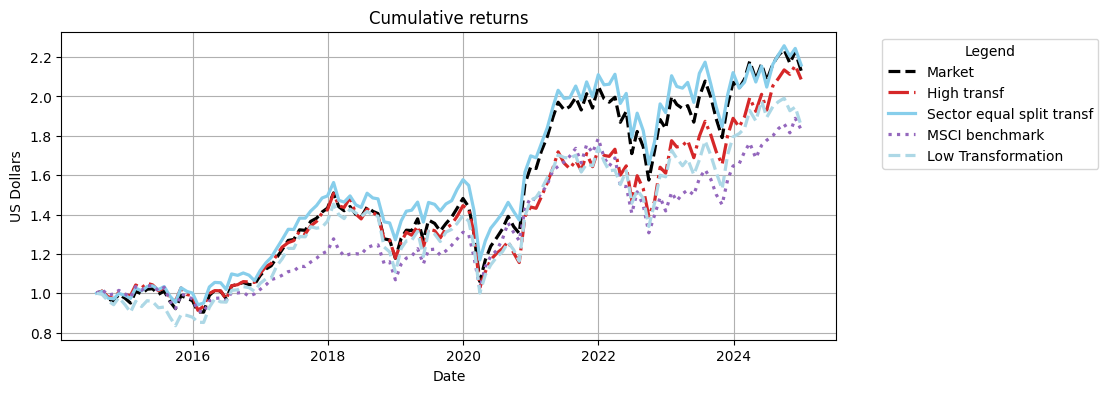

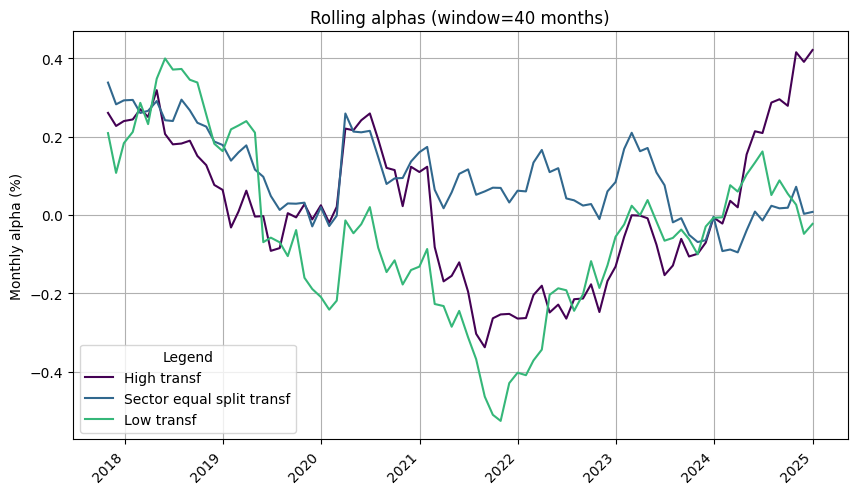

,1m,3m,YTD,1yr,3yr,5yr,10yr,Since launch
Market,-4.38%,-4.81%,2.81%,2.81%,3.78%,43.76%,118.47%,113.02%
High transf,-3.28%,-2.26%,10.46%,10.46%,20.54%,44.40%,110.15%,108.68%
Sector equal split transf,-3.78%,-4.35%,1.82%,1.82%,2.32%,36.93%,118.33%,115.97%
MSCI benchmark,-3.06%,-1.56%,11.21%,11.21%,2.52%,39.80%,83.63%,83.13%
Low Transformation,-4.88%,-7.04%,3.14%,3.14%,6.21%,32.69%,96.41%,85.10%


,Sharpe,VaR 1%,Max Drawdown,Alpha,p-value(alpha)
Market,0.50,-10.79%,-29.81%,,
High transf,0.49,-10.28%,-31.75%,0.06,0.660
Sector equal split transf,0.52,-10.63%,-25.86%,0.10,0.440
MSCI benchmark,0.46,-9.45%,-26.82%,,
Low Transformation,0.42,-10.99%,-31.09%,,


<Axes: title={'center': 'Rolling Annualised Sharpe (24-month window)'}, ylabel='Sharpe'>

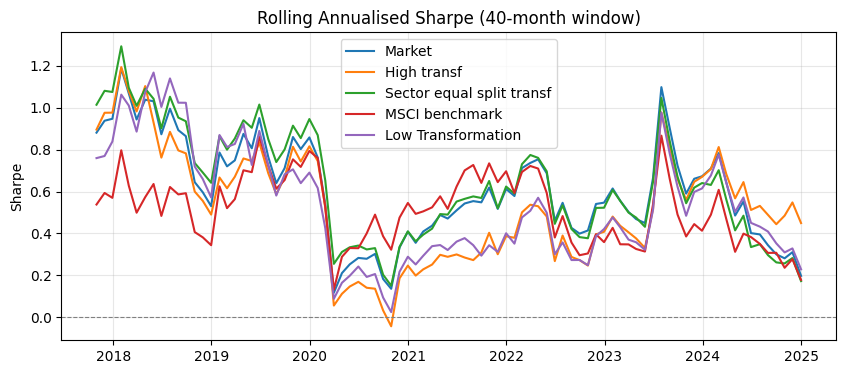

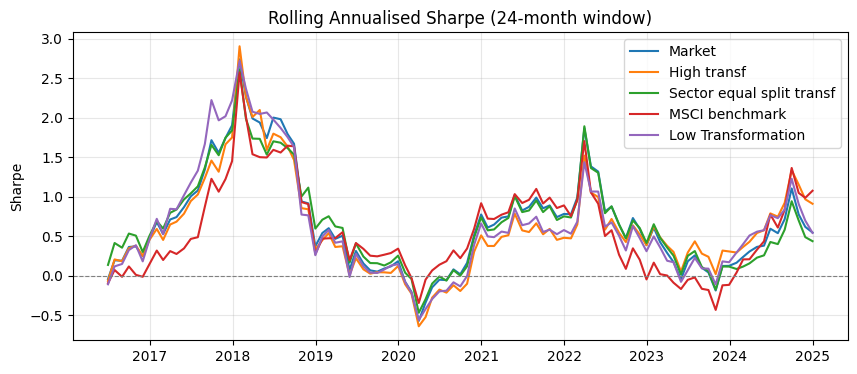

In [50]:
from functions.Strategy_Perfomance import StrategyPerformance
from functions.fama_french import plot_rolling_alpha_function



start_date = str(portfolio_returns.index[0])[:7]
end_date = str(portfolio_returns.index[-1])[:7]

sp = StrategyPerformance(portfolio_returns, ff3_parts_df=ff3_parts_df)


cumulative_table = sp.cumulative_performance_table(
    csv_path=f"./output/strategy_cumulative_performance_{start_date}-{end_date}.csv")

risk_table = sp.performance_risk_metrics_table(
    csv_path=f"./output/strategy_performance_metrics_{start_date}-{end_date}.csv")



sp.plot_cumulative_returns(
    title="Cumulative returns",
    tight_layout_rect = (0, 5, 100, 0.9),
    save_path=f"./output/img/cumulative_returns_{start_date}-{end_date}.png"
)

# Note: sector-split alpha is appended later once `sector_portfolio_returns` exists.
plot_rolling_alpha_function(
    rolling_alphas,
    title="Rolling alphas (window=40 months)",
    save_path="./output/img/rolling_alphas_{start_date}-{end_date}.png",
)

display(cumulative_table)
display(risk_table)


sp.plot_rolling_sharpe(window=40, save_path=f"./output/img/strategy_rolling_sharpe_40m_{start_date}-{end_date}.png")
#sp.plot_rolling_sharpe(window=60, save_path=f"./output/img/strategy_rolling_sharpe_60m_{start_date}-{end_date}.png")
sp.plot_rolling_sharpe(window=24, save_path=f"./output/img/strategy_rolling_sharpe_24m_{start_date}-{end_date}.png")


# 7. Portfolio Constituents

### Portfolio constituents — category mix (`PortfolioConstituents`)

Uses `signal_2_simple_quantiles_constituents` and `global_universe` to inspect **Industry**, **`loc`**, and **MacroRegion**: line charts of stock counts over time (default = last quantile `p_k`, same as `constituents[i][-1]`) and donut charts for the **final** formation month. Optional: `analyse_all_portfolios_at_once=True` unions all `p_1`…`p_k`; `all_sub_portfolios=True` plots one subplot per quantile.


The following only inspects the high transformation

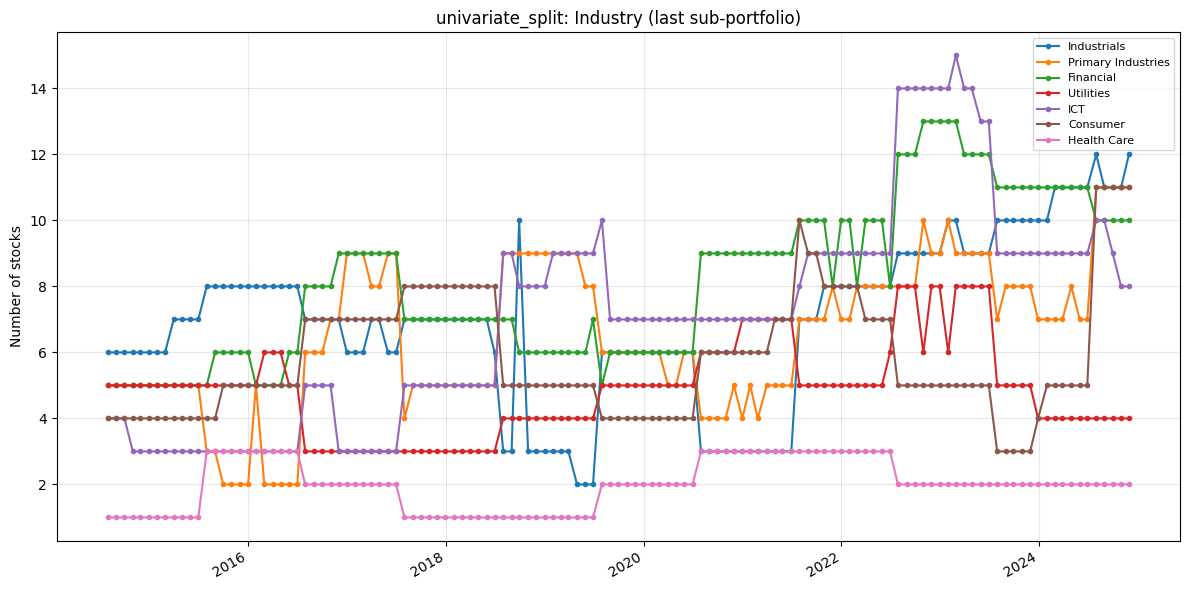

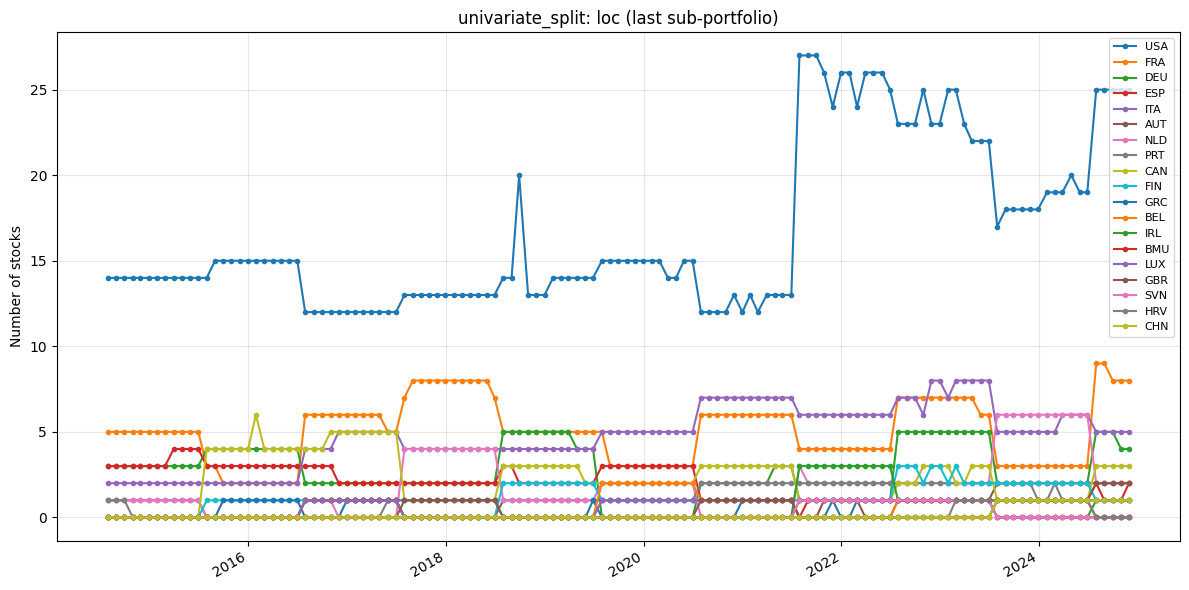

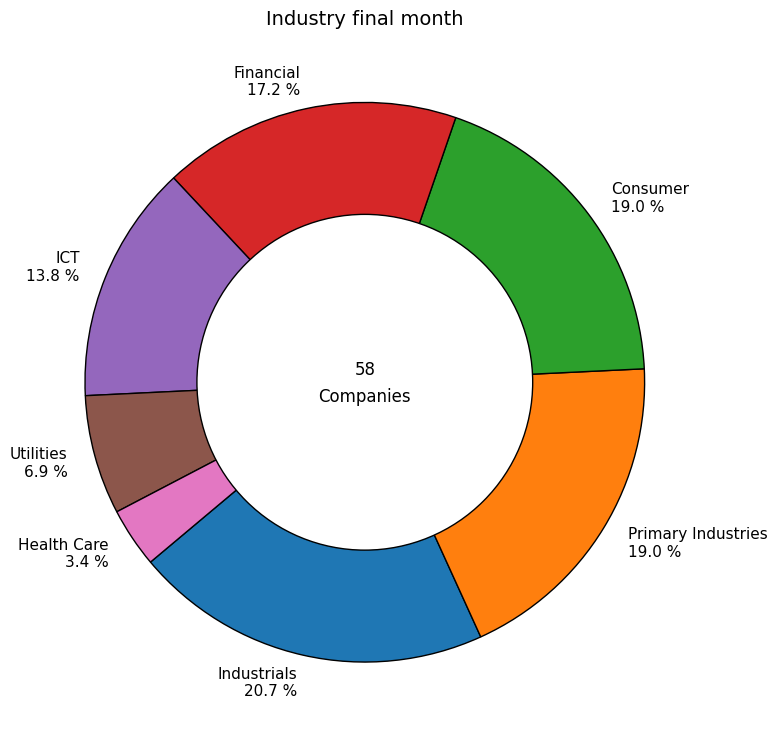

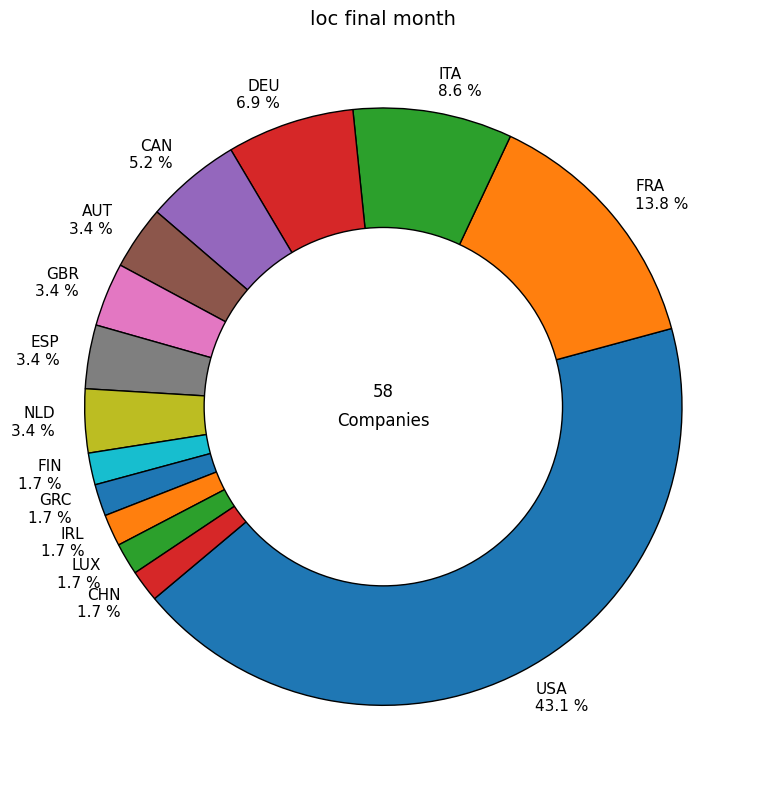

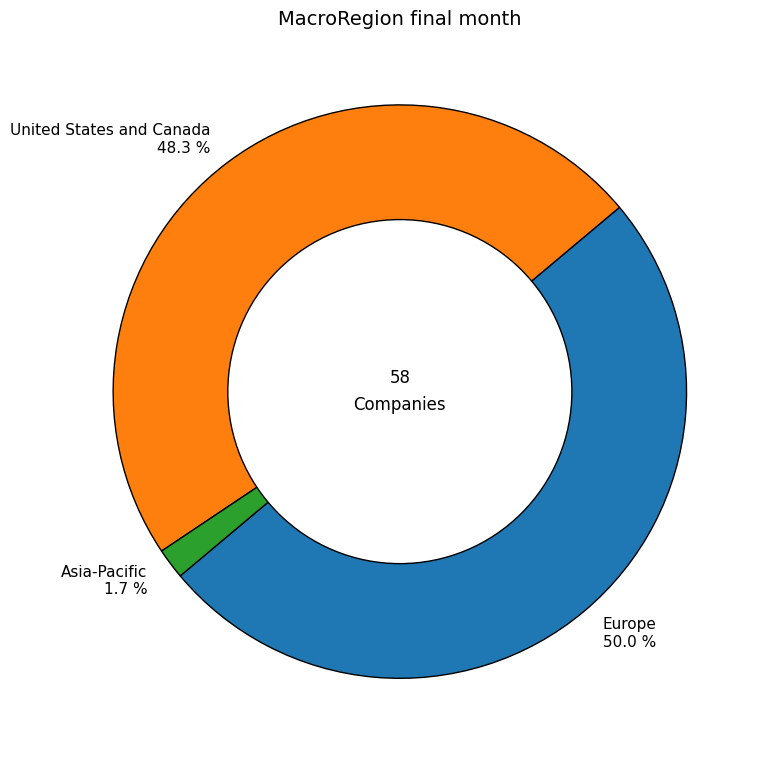

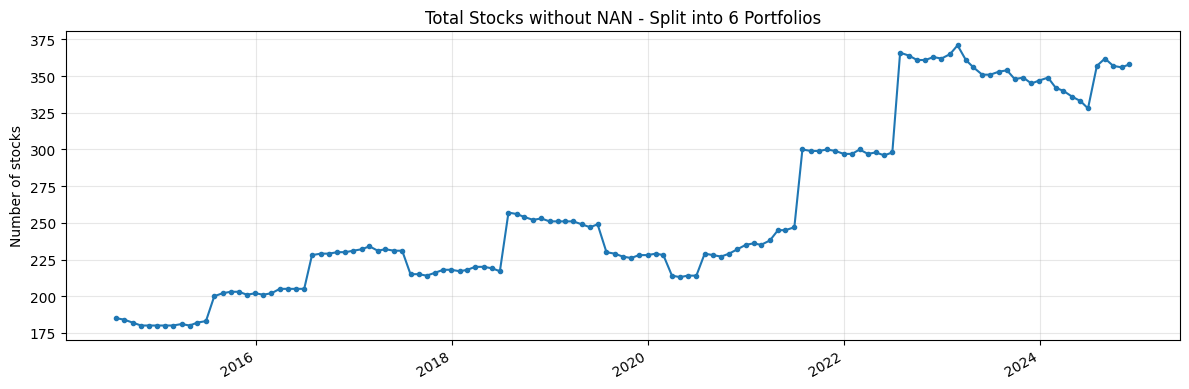

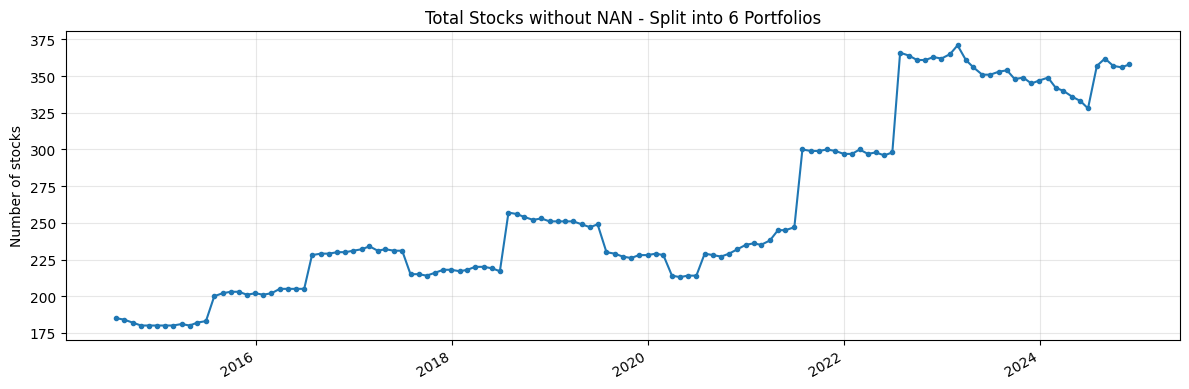

In [51]:
from IPython.display import display
from functions.Portfolio_Constituents import PortfolioConstituents

pc2 = PortfolioConstituents(
    signal_2_simple_quantiles_constituents,
    global_universe,
    portfolio_type="univariate_split",
)




_dates, wide_industry = pc2._counts_by_category_over_time(
    "Industry",
    portfolio_key=None,  # ignored when analyse_all_portfolios_at_once=True
    analyse_all_portfolios_at_once=False,
)

pc2.run_all_plots(save=True, show=True)

# Options:
#pc2.run_all_plots(analyse_all_portfolios_at_once=True, save=True, show=True)
#pc2.run_all_plots(all_sub_portfolios=True, save=True, show=True)
# Plot (like your snippet)
pc2.total_stocks_over_time(title=f"Total Stocks without NAN - Split into {no_simple_quantiles} Portfolios")
